# 📘 Session 17: Introduction to Supervised Learning
### Duration: ~2.5–3 Hours

---

**Topics Covered:**
1. Supervised Learning Workflow — Recap and Classification
2. The scikit-learn Modeling API — `fit`, `predict`, `predict_proba`
3. First Classifier — Logistic Regression
4. Evaluating Classifiers — Accuracy, Confusion Matrix, Classification Report
5. Second Classifier — Random Forest
6. Full Pipeline — Preprocessing + Model Together
7. Comparing Models and Next Steps

---

**Why This Session Matters for Data Science:**
- **Session 16** prepared model-ready data; today we **train and evaluate** first models
- **Classification** is one of the most common ML tasks (spam, churn, diagnosis, species ID)
- **Metrics** tell you whether the model is useful — accuracy alone is not enough
- **Pipelines** keep preprocessing and modeling bundled so you cannot leak test data

> **Prerequisites:** Session 16 preprocessing (train/test split, encoders, scalers, `Pipeline`). We use the same **Palmer Penguins** dataset: predict `species` from measurements.

> **Not in this session:** hyperparameter tuning, cross-validation, regression targets, deep learning.

**Libraries:** `pandas`, `numpy`, `seaborn`, `matplotlib`, **`scikit-learn`**


---
## 1. Supervised Learning Workflow — Recap

```mermaid
flowchart LR
  data[RawData] --> split[TrainTestSplit]
  split --> prep[PreprocessOnTrain]
  prep --> model[FitModel]
  model --> pred[PredictOnTest]
  pred --> metrics[EvaluateMetrics]
```

### Classification vs regression (today: classification)

| Task | Target type | Example | Metric examples |
|------|-------------|---------|-----------------|
| **Classification** | Categories | Predict penguin species | Accuracy, confusion matrix |
| **Regression** | Numbers | Predict body mass in grams | MAE, RMSE (later session) |

### Our project today

| Item | Choice |
|------|--------|
| **Target (y)** | `species` (3 classes: Adelie, Chinstrap, Gentoo) |
| **Features (X)** | Bill/flipper/mass measurements, island, sex, bill_ratio |
| **Train / test** | 80/20 stratified split (Session 16) |
| **Models** | Logistic Regression, Random Forest |

> ⚠️ **Special Case — train vs test**: Metrics on **test** data estimate real-world performance. Never tune or pick a model using test labels repeatedly (that leaks information).

> **Data Science relevance**: A simple, well-evaluated baseline model beats a complex model nobody trusts.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# --- Same setup as Session 16 ---
raw = sns.load_dataset("penguins")
complete = raw.dropna(
    subset=[
        "species", "island", "sex",
        "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g",
    ]
).copy()
complete["bill_ratio"] = complete["bill_length_mm"] / complete["bill_depth_mm"]

y = complete["species"]
X = complete.drop(columns=["species"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

numeric_features = [
    "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "bill_ratio",
]
categorical_features = ["island", "sex"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Classes:", y_train.unique().tolist())


Train: (266, 7) | Test: (67, 7)
Classes: ['Gentoo', 'Chinstrap', 'Adelie']


---
## 2. The scikit-learn Modeling API

Every supervised model in scikit-learn follows the same pattern:

| Step | Method | Purpose |
|------|--------|---------|
| **Train** | `.fit(X_train, y_train)` | Learn patterns from labeled data |
| **Predict class** | `.predict(X_test)` | Hard labels (e.g., Adelie) |
| **Predict probability** | `.predict_proba(X_test)` | Class probabilities (if supported) |

```python
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

> **Data Science relevance**: This uniform API lets you swap Logistic Regression for Random Forest with minimal code changes.


---
## 3. First Classifier — Logistic Regression

**Logistic Regression** is a classic **linear** classifier. Despite the name, it predicts **class probabilities** for classification problems.

| Property | Detail |
|----------|--------|
| **Strengths** | Fast, interpretable, strong baseline |
| **Needs scaling?** | Yes — benefits from Session 16 `StandardScaler` |
| **Multi-class** | Handles 3 species natively (`multi_class` strategies) |

We preprocess first, then fit on the transformed training matrix.


In [9]:
from sklearn.linear_model import LogisticRegression

prep = Pipeline([("preprocessor", preprocessor)])

X_train_processed = prep.fit_transform(X_train, y_train)
X_test_processed = prep.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
print("preprocced x train values:", X_train_processed[:5])
print("preprocced y train values:", y_train.head())
log_reg.fit(X_train_processed, y_train)

y_pred_lr = log_reg.predict(X_test_processed)
y_proba_lr = log_reg.predict_proba(X_test_processed)

print("First 5 predictions:", y_pred_lr[:5])
print("Probability shape:", y_proba_lr.shape)
print("Classes order:", log_reg.classes_)


preprocced x train values: [[ 0.16732502 -1.99231135  0.83478089  1.08239437  1.56870611  1.
   0.          0.          1.          0.        ]
 [ 1.22705014  1.25552054  0.1212471  -0.21564233 -0.04941166  0.
   1.          0.          0.          1.        ]
 [ 0.87989881 -0.52063753  1.4769613   2.19499725  0.83542437  1.
   0.          0.          0.          1.        ]
 [-0.47216428  0.64655206  0.04989372 -0.43198178 -0.72657114  0.
   0.          1.          0.          1.        ]
 [-1.16646695  1.05253105 -1.44852725 -1.1428114  -1.31072797  0.
   1.          0.          1.          0.        ]]
preprocced y train values: 268       Gentoo
205    Chinstrap
337       Gentoo
123       Adelie
38        Adelie
Name: species, dtype: str
First 5 predictions: ['Gentoo' 'Chinstrap' 'Adelie' 'Gentoo' 'Gentoo']
Probability shape: (67, 3)
Classes order: ['Adelie' 'Chinstrap' 'Gentoo']


---
## 4. Evaluating Classifiers

### Accuracy

**Accuracy** = fraction of correct predictions on the test set.

$$\text{accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

Good for balanced classes; misleading when one class dominates.

### Confusion matrix

Rows = **true** class, columns = **predicted** class. Shows *which* mistakes happen.

### Classification report

Per-class **precision**, **recall**, and **F1-score** (harmonic mean of precision and recall).

| Metric | Question it answers |
|--------|---------------------|
| **Precision** | Of predicted Adelie, how many were actually Adelie? |
| **Recall** | Of actual Adelie, how many did we find? |
| **F1** | Balance of precision and recall |


Logistic Regression test accuracy: 1.000

Classification report:

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



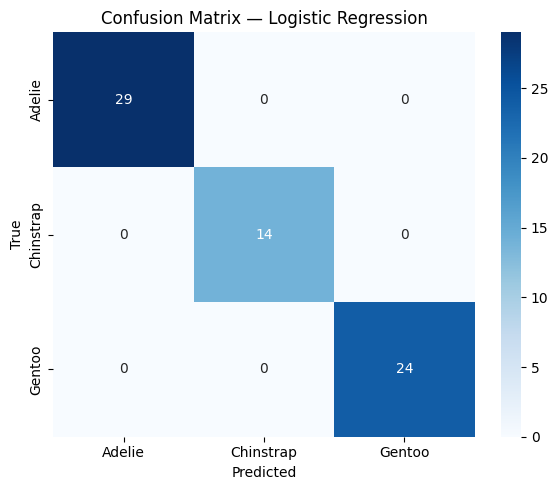

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression test accuracy: {acc_lr:.3f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr, labels=log_reg.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=log_reg.classes_, yticklabels=log_reg.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()


---
## 5. Second Classifier — Random Forest

**Random Forest** = ensemble of many decision trees voting on the outcome.

| Property | Detail |
|----------|--------|
| **Strengths** | Captures non-linear boundaries; often strong out of the box |
| **Needs scaling?** | Usually no (Session 16 note) — we keep same preprocessor for fair comparison |
| **Interpretability** | Feature importances available |

Same preprocessed matrices; swap the model only.


Random Forest test accuracy: 1.000

Classification report:

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



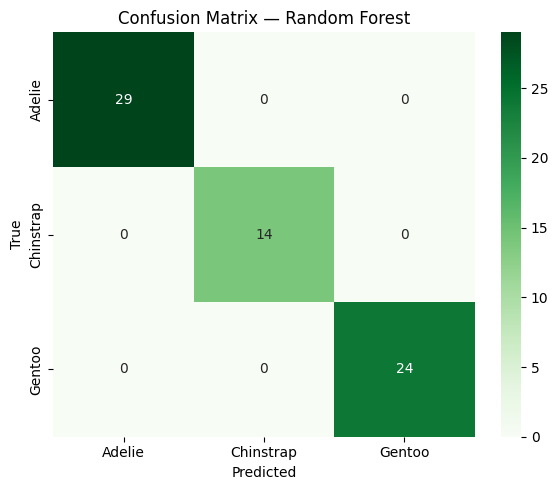

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest test accuracy: {acc_rf:.3f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=rf.classes_, yticklabels=rf.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()


---
## 6. Full Pipeline — Preprocessing + Model Together

Best practice: one `Pipeline` object containing **preprocessor + classifier**. Prevents accidental leakage and simplifies deployment.

```python
Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(...)),
])
```

Fit once on raw `X_train` (DataFrame with column names) — preprocessing happens inside.


In [5]:
from sklearn.pipeline import Pipeline as SkPipeline

full_pipeline = SkPipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
])

full_pipeline.fit(X_train, y_train)
y_pred_pipe = full_pipeline.predict(X_test)
print(f"Pipeline test accuracy: {accuracy_score(y_test, y_pred_pipe):.3f}")

# Same result as separate prep + rf when random_state and data match
print("Matches separate RF?", np.array_equal(y_pred_pipe, y_pred_rf))


Pipeline test accuracy: 1.000
Matches separate RF? True


---
## 7. Comparing Models and Next Steps

| Model | Test accuracy (your run) | Notes |
|-------|--------------------------|-------|
| Logistic Regression | See above | Linear baseline; fast |
| Random Forest | See above | Often wins on tabular data |

### Quick comparison bar chart

Use test accuracy for a first comparison — later sessions add cross-validation and more metrics.

### Feature importances (Random Forest)

Which inputs drove the forest? Useful for storytelling after EDA.


                 model  test_accuracy
0  Logistic Regression            1.0
1        Random Forest            1.0


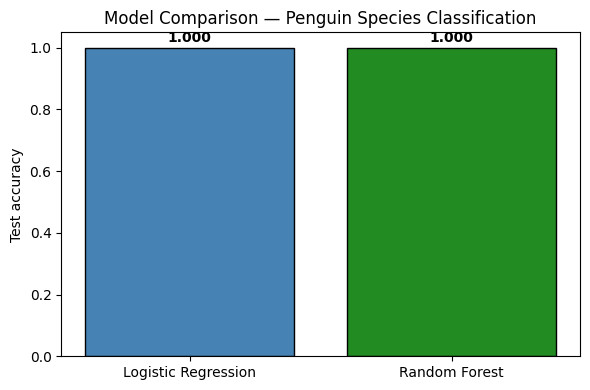


Top 10 feature importances:
                feature  importance
       num__bill_ratio    0.328922
   num__bill_length_mm    0.201493
num__flipper_length_mm    0.149575
    num__bill_depth_mm    0.089688
     cat__island_Dream    0.089624
    cat__island_Biscoe    0.075236
      num__body_mass_g    0.055902
 cat__island_Torgersen    0.006153
         cat__sex_Male    0.002411
       cat__sex_Female    0.000997


In [6]:
results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "test_accuracy": [acc_lr, acc_rf],
})
print(results)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(results["model"], results["test_accuracy"], color=["steelblue", "forestgreen"], edgecolor="black")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test accuracy")
ax.set_title("Model Comparison — Penguin Species Classification")
for i, v in enumerate(results["test_accuracy"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# Feature importances from pipeline RF
feature_names = full_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = full_pipeline.named_steps["classifier"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(10)
print("\nTop 10 feature importances:\n", imp_df.to_string(index=False))


---
## 🧪 Practice Exercises

1. Print `y_train.value_counts(normalize=True)` and `y_test.value_counts(normalize=True)` — is stratification working?
2. Train Logistic Regression with `max_iter=50` only — does it converge? Increase until warnings disappear.
3. From the confusion matrix, which **species pair** is confused most often?
4. Retrain Random Forest with `n_estimators=10` vs `200` — how much does test accuracy change?
5. Build a full `Pipeline` with **LogisticRegression** as the classifier instead of RF. Compare test accuracy.
6. Pick one misclassified test row: print its true label, predicted label, and `predict_proba` for RF.
7. Why might **100% test accuracy** on this dataset still not mean "production ready"? (Think: sample size, new islands, measurement error.)
8. Write a 5-bullet **modeling memo**: target, models tried, best test metric, main error pattern, recommended next step (e.g. cross-validation in Session 18).

---

## 📝 Session 17 Summary

| Topic | Key takeaway |
|-------|--------------|
| **Supervised workflow** | Split → preprocess on train → fit → predict → evaluate on test |
| **API** | `.fit()`, `.predict()`, `.predict_proba()` |
| **Logistic Regression** | Strong linear baseline for classification |
| **Random Forest** | Non-linear ensemble; feature importances |
| **Metrics** | Accuracy + confusion matrix + classification report |
| **Full Pipeline** | Preprocessor + model in one object |

### Key gotchas
- High **accuracy** can hide poor performance on rare classes — read the classification report
- **Never** use test labels to choose preprocessing or model settings repeatedly
- **Logistic Regression** needs scaled features; trees are less sensitive but we kept one pipeline pattern
- Compare models on the **same** train/test split for fairness

### Next Session
**Session 18**: Model Evaluation Beyond Accuracy — cross-validation, precision/recall tradeoffs, and choosing metrics for imbalanced data.
